# Line-Ending Detector: a file has no lines in it

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/line-ending-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/line-ending-detector/demo.ipynb)

**Day 151 of the FDE portfolio.** A file has bytes. *Lines* are produced by a
splitter, and every runtime ships a different one:

- `wc -l` counts LF bytes, so an unterminated last line is not a line.
- Python text mode rewrites CRLF and lone CR to LF **before your code sees the string**.
- `str.splitlines()` breaks on eleven boundaries, including VT, FF, NEL and U+2028.
- `csv.reader` keeps a CRLF that sits inside quotes, because there it is data.

So three questions have different answers per runtime: **how many lines is
this file**, **what is on each line**, and **is reading and writing it back
the identity**.

What this notebook builds:

1. fifteen byte blobs, each one an export somebody actually receives
2. ten splitters, lifted verbatim from the engine
3. the line-count matrix, and the four verdicts
4. the carriage return that survives into a parsed value
5. read-then-write, and the rewrites that land inside a value
6. the one-field edit that shows up as a whole-file diff
7. streaming: a CRLF straddling a chunk boundary
8. "detect the line ending", which for a third of these files has no answer


## 1. The files

Every blob below is ordinary. The interesting ones are not corrupt - they are
what you get from a Windows export, an old Mac, a form field somebody pasted
into, or an FTP transfer in ASCII mode.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple

CR, LF, CRLF = b"\r", b"\n", b"\r\n"


@dataclass(frozen=True)
class Blob:
    id: int
    label: str
    data: bytes
    note: str

    @property
    def display(self) -> str:
        """The bytes with the invisible ones named."""
        out = []
        for b in self.data:
            ch = bytes([b])
            if ch == b"\r":
                out.append("<CR>")
            elif ch == b"\n":
                out.append("<LF>\n")
            elif b == 0x0B:
                out.append("<VT>")
            elif b == 0x0C:
                out.append("<FF>")
            elif b < 0x20:
                out.append(f"<{b:02X}>")
            elif b > 0x7E:
                out.append(f"<{b:02X}>")
            else:
                out.append(chr(b))
        return "".join(out)

    @property
    def one_line(self) -> str:
        return self.display.replace("\n", "")


CORPUS: Tuple[Blob, ...] = (
    Blob(1, "lf-only", b"id,name\n1,Alice\n2,Bob\n", "the file everyone assumes they have"),
    Blob(2, "crlf-only", b"id,name\r\n1,Alice\r\n2,Bob\r\n", "any export written on Windows"),
    Blob(3, "cr-only", b"id,name\r1,Alice\r2,Bob\r", "classic Mac, and some Excel-for-Mac exports"),
    Blob(4, "mixed-lf-crlf", b"id,name\n1,Alice\r\n2,Bob\n", "two editors, one file"),
    Blob(5, "no-trailing-newline", b"id,name\n1,Alice\n2,Bob", "the last line ends with nothing"),
    Blob(
        6,
        "crlf-inside-quotes",
        b'id,note\r\n1,"line one\r\nline two"\r\n2,plain\r\n',
        "a CRLF that is data, not structure",
    ),
    Blob(
        7,
        "lone-cr-in-value",
        b'id,name\n1,"Smith\rJones"\n2,Bob\n',
        "a stray CR pasted into a form field",
    ),
    Blob(8, "nel-u0085", b"id,name\n1,A\xc2\x85B\n", "U+0085 NEL, which splitlines() breaks on"),
    Blob(
        9,
        "ls-u2028",
        b'{"bio": "para one\xe2\x80\xa8para two"}\n',
        "U+2028 in a JSON string - legal JSON, and a line break to Python",
    ),
    Blob(10, "vertical-tab", b"id,addr\n1,Flat 3\x0bLondon\n", "VT in an address field"),
    Blob(11, "form-feed", b"page one\x0cpage two\n", "FF as a page separator, from a report"),
    Blob(12, "bom-crlf", b"\xef\xbb\xbfid,name\r\n1,Alice\r\n", "UTF-8 BOM in front of a CRLF file"),
    Blob(13, "lf-then-cr", b"a\n\rb\n\r", "LF CR, the wrong way round - a botched conversion"),
    Blob(14, "double-converted", b"a\r\r\nb\r\r\n", "CRLF converted to CRLF again, over FTP ASCII"),
    Blob(15, "blank-lines-mixed", b"a\r\n\r\nb\n\nc\r\n", "blank lines under two conventions"),
)


print(f"{len(CORPUS)} blobs\n")
for b in CORPUS:
    print(f"{b.id:2d}  {b.label:22s} {len(b.data):3d} bytes  {b.note}")
    print(f"    {b.one_line}")

15 blobs

 1  lf-only                 22 bytes  the file everyone assumes they have
    id,name<LF>1,Alice<LF>2,Bob<LF>
 2  crlf-only               25 bytes  any export written on Windows
    id,name<CR><LF>1,Alice<CR><LF>2,Bob<CR><LF>
 3  cr-only                 22 bytes  classic Mac, and some Excel-for-Mac exports
    id,name<CR>1,Alice<CR>2,Bob<CR>
 4  mixed-lf-crlf           23 bytes  two editors, one file
    id,name<LF>1,Alice<CR><LF>2,Bob<LF>
 5  no-trailing-newline     21 bytes  the last line ends with nothing
    id,name<LF>1,Alice<LF>2,Bob
 6  crlf-inside-quotes      42 bytes  a CRLF that is data, not structure
    id,note<CR><LF>1,"line one<CR><LF>line two"<CR><LF>2,plain<CR><LF>
 7  lone-cr-in-value        30 bytes  a stray CR pasted into a form field
    id,name<LF>1,"Smith<CR>Jones"<LF>2,Bob<LF>
 8  nel-u0085               15 bytes  U+0085 NEL, which splitlines() breaks on
    id,name<LF>1,A<C2><85>B<LF>
 9  ls-u2028                31 bytes  U+2028 in a JSON string - lega

## 2. Ten splitters

Lifted verbatim from `lineends.py`. Four are the standard library doing
exactly what it documents; the rest are faithful models of another runtime's
reader.


In [2]:
import csv
import io
from typing import Callable, List, Optional, Sequence


def _strip_bom(data: bytes) -> bytes:
    return data[3:] if data.startswith(b"\xef\xbb\xbf") else data


def split_lf(data: bytes) -> List[bytes]:
    """`data.split(b"\\n")` - the one most pipelines actually use.

    A CR before the LF stays on the end of the line, invisibly.
    """
    parts = data.split(LF)
    if parts and parts[-1] == b"":
        parts = parts[:-1]
    return parts


def split_wc(data: bytes) -> List[bytes]:
    """`wc -l` - counts LF bytes, so a file with no trailing newline is one
    line short of what you see in an editor."""
    parts = data.split(LF)
    return parts[:-1]


def split_universal(data: bytes) -> List[bytes]:
    """Python text mode, `open(..., newline=None)`.

    CRLF and lone CR are rewritten to LF *before* your code sees the string,
    which is why the bug is invisible from inside Python.
    """
    text = _strip_bom(data).replace(CRLF, LF).replace(CR, LF)
    parts = text.split(LF)
    if parts and parts[-1] == b"":
        parts = parts[:-1]
    return parts


def split_newline_empty(data: bytes) -> List[bytes]:
    """`open(..., newline="")` - splits on all three, translates none."""
    out: List[bytes] = []
    cur = bytearray()
    i = 0
    data = _strip_bom(data)
    while i < len(data):
        ch = data[i : i + 1]
        if ch == CR:
            if data[i + 1 : i + 2] == LF:
                i += 1
            out.append(bytes(cur))
            cur = bytearray()
        elif ch == LF:
            out.append(bytes(cur))
            cur = bytearray()
        else:
            cur += ch
        i += 1
    if cur:
        out.append(bytes(cur))
    return out


def split_splitlines(data: bytes) -> List[bytes]:
    """`str.splitlines()` - breaks on eight boundaries, not one.

    LF, CR, CRLF, VT, FF, FS, GS, RS, NEL, U+2028, U+2029. Any of those
    arriving inside a data value silently becomes a new row.
    """
    text = _strip_bom(data).decode("utf-8", "surrogateescape")
    return [ln.encode("utf-8", "surrogateescape") for ln in text.splitlines()]


def split_bytes_splitlines(data: bytes) -> List[bytes]:
    """`bytes.splitlines()` - the same call on bytes, and a *different*
    boundary set: no NEL, no U+2028, but VT and FF still split."""
    return _strip_bom(data).splitlines()


def split_java(data: bytes) -> List[bytes]:
    """`BufferedReader.readLine()` - LF, CR and CRLF, and it drops the final
    empty line."""
    return split_newline_empty(data)


def split_js(data: bytes) -> List[bytes]:
    """JavaScript's usual `text.split(/\\r?\\n/)` - a lone CR is left inside
    the line, where it will be printed and not seen."""
    text = _strip_bom(data)
    parts = text.replace(CRLF, LF).split(LF)
    if parts and parts[-1] == b"":
        parts = parts[:-1]
    return parts


def split_csv(data: bytes) -> List[bytes]:
    """`csv.reader` over `newline=""` - the only splitter here that knows a
    line terminator inside quotes is data."""
    text = _strip_bom(data).decode("utf-8", "surrogateescape")
    rows = list(csv.reader(io.StringIO(text, newline="")))
    return [",".join(r).encode("utf-8", "surrogateescape") for r in rows]


def split_git_text_auto(data: bytes) -> List[bytes]:
    """`* text=auto` - normalises CRLF to LF on commit, then LF-splits. The
    normalisation is what makes the diff say every line changed."""
    return split_lf(_strip_bom(data).replace(CRLF, LF))


@dataclass(frozen=True)
class Splitter:
    key: str
    models: str
    fn: Callable[[bytes], List[bytes]]
    note: str = ""


SPLITTERS: Tuple[Splitter, ...] = (
    Splitter("split_lf", 'data.split(b"\\n") in any pipeline', split_lf,
             "leaves a CR on the end of every line of a CRLF file"),
    Splitter("wc_l", "wc -l, and POSIX's definition of a line", split_wc,
             "counts LF bytes; an unterminated last line is not a line"),
    Splitter("py_universal", "Python open(newline=None), pandas, most readers", split_universal,
             "rewrites CRLF and CR to LF before your code sees the text"),
    Splitter("py_newline_empty", 'Python open(newline="")', split_newline_empty,
             "splits on all three, translates none"),
    Splitter("str_splitlines", "str.splitlines()", split_splitlines,
             "eleven boundaries including VT, FF, NEL and U+2028"),
    Splitter("bytes_splitlines", "bytes.splitlines()", split_bytes_splitlines,
             "a different boundary set from the str version"),
    Splitter("java_readline", "BufferedReader.readLine(), Go bufio.Scanner", split_java,
             "LF, CR and CRLF"),
    Splitter("js_split", "JS text.split(/\\r?\\n/)", split_js,
             "a lone CR stays inside the line"),
    Splitter("csv_reader", 'csv.reader over newline=""', split_csv,
             "the only one that treats a terminator inside quotes as data"),
    Splitter("git_text_auto", "git * text=auto (normalise on commit)", split_git_text_auto,
             "rewrites the file, then splits"),
)


SPLITTER_BY_KEY = {s.key: s for s in SPLITTERS}


def lines(blob, sp):
    return sp.fn(blob.data)


def line_count(blob, sp):
    return len(lines(blob, sp))


for s in SPLITTERS:
    print(f"  {s.key:18s} {s.models}")

  split_lf           data.split(b"\n") in any pipeline
  wc_l               wc -l, and POSIX's definition of a line
  py_universal       Python open(newline=None), pandas, most readers
  py_newline_empty   Python open(newline="")
  str_splitlines     str.splitlines()
  bytes_splitlines   bytes.splitlines()
  java_readline      BufferedReader.readLine(), Go bufio.Scanner
  js_split           JS text.split(/\r?\n/)
  csv_reader         csv.reader over newline=""
  git_text_auto      git * text=auto (normalise on commit)


## 3. How many lines is this file?

In [3]:
import pandas as pd

counts = pd.DataFrame(
    [[line_count(b, s) for s in SPLITTERS] for b in CORPUS],
    index=[b.label for b in CORPUS],
    columns=[s.key for s in SPLITTERS],
)
counts["min"] = counts.min(axis=1)
counts["max"] = counts.max(axis=1)
drifting = counts[counts["min"] != counts["max"]]
print(f"{len(drifting)} of {len(CORPUS)} files get a different line COUNT depending on "
      f"the reader\n")
counts

10 of 15 files get a different line COUNT depending on the reader



,split_lf,wc_l,py_universal,py_newline_empty,str_splitlines,bytes_splitlines,java_readline,js_split,csv_reader,git_text_auto,min,max
lf-only,3,3,3,3,3,3,3,3,3,3,3,3
crlf-only,3,3,3,3,3,3,3,3,3,3,3,3
cr-only,1,0,3,3,3,3,3,1,3,1,0,3
mixed-lf-crlf,3,3,3,3,3,3,3,3,3,3,3,3
no-trailing-newline,3,2,3,3,3,3,3,3,3,3,2,3
crlf-inside-quotes,4,4,4,4,4,4,4,4,3,4,3,4
lone-cr-in-value,3,3,4,4,4,4,4,3,3,3,3,4
nel-u0085,2,2,2,2,3,2,2,2,2,2,2,3
ls-u2028,1,1,1,1,2,1,1,1,1,1,1,2
vertical-tab,2,2,2,2,3,2,2,2,2,2,2,3


### Four verdicts

- `agreed` - same count and same bytes from all ten
- `content-drift` - same count, different bytes: every count-based check passes
- `count-drift` - they do not agree how many lines there are
- `data-split` - a terminator inside a value becomes a row


In [4]:
from enum import Enum


class Verdict(str, Enum):
    AGREED = "agreed"
    CONTENT_DRIFT = "content-drift"
    COUNT_DRIFT = "count-drift"
    DATA_SPLIT = "data-split"


def verdict(blob):
    counts_ = {line_count(blob, s) for s in SPLITTERS}
    csv_n = line_count(blob, SPLITTER_BY_KEY["csv_reader"])
    others = {line_count(blob, s) for s in SPLITTERS if s.key != "csv_reader"}
    if len(counts_) > 1 and csv_n < min(others):
        return Verdict.DATA_SPLIT
    if len(counts_) > 1:
        return Verdict.COUNT_DRIFT
    if len({tuple(lines(blob, s)) for s in SPLITTERS}) > 1:
        return Verdict.CONTENT_DRIFT
    return Verdict.AGREED


verdicts = {v: [b.label for b in CORPUS if verdict(b) is v] for v in Verdict}
for v, labels in verdicts.items():
    print(f"{v.value:<14s} {len(labels):2d}  {', '.join(labels)}")

agreed          1  lf-only
content-drift   4  crlf-only, mixed-lf-crlf, bom-crlf, blank-lines-mixed
count-drift     9  cr-only, no-trailing-newline, lone-cr-in-value, nel-u0085, ls-u2028, vertical-tab, form-feed, lf-then-cr, double-converted
data-split      1  crlf-inside-quotes


One file in fifteen is read identically by every runtime here, and it
is the boring one: LF, terminated, nothing exotic in a value.

## 4. The carriage return that is still in the value


In [5]:
def trailing_cr(blob, sp):
    return [ln for ln in lines(blob, sp) if ln.endswith(CR)]


cr = {s.key: sum(len(trailing_cr(b, s)) for b in CORPUS) for s in SPLITTERS}
for k, v in cr.items():
    print(f"  {k:18s} {v:3d}{'   <-- CR-blind' if v else ''}")

b = next(x for x in CORPUS if x.label == "crlf-only")
raw = trailing_cr(b, SPLITTER_BY_KEY["split_lf"])[1]
clean = lines(b, SPLITTER_BY_KEY["py_universal"])[1]
print(f"\ncrlf-only, line 2:")
print(f"  split_lf      {raw!r}")
print(f"  py_universal  {clean!r}")
print(f"  printed       {raw.decode()}| vs {clean.decode()}|")
print(f"  equal?        {raw == clean}")
try:
    int(raw.split(b",")[-1])
except ValueError as exc:
    print(f"  int(last field) -> ValueError: {exc}")

  split_lf            17   <-- CR-blind
  wc_l                15   <-- CR-blind
  py_universal         0
  py_newline_empty     0
  str_splitlines       0
  bytes_splitlines     0
  java_readline        0
  js_split             4   <-- CR-blind
  csv_reader           0
  git_text_auto        4   <-- CR-blind

crlf-only, line 2:
  split_lf      b'1,Alice\r'
  py_universal  b'1,Alice'
| vs 1,Alice|
  equal?        False
  int(last field) -> ValueError: invalid literal for int() with base 10: b'Alice\r'


## 5. When the terminator is the data - and when it is invented

`csv.reader` is the only splitter here that knows a quoted CRLF is a value.
`str.splitlines()` goes the other way and finds boundaries no terminator set
contains.


In [6]:
b = next(x for x in CORPUS if x.label == "crlf-inside-quotes")
print(b.one_line, "\n")
for key in ("csv_reader", "py_universal"):
    got = lines(b, SPLITTER_BY_KEY[key])
    print(f"  {key:14s} {len(got)} rows: {[x.decode() for x in got]}")

print("\nsplitlines() inventing rows:")
for x in CORPUS:
    a = line_count(x, SPLITTER_BY_KEY["str_splitlines"])
    c = line_count(x, SPLITTER_BY_KEY["py_universal"])
    if a != c:
        print(f"  {x.label:<18s} splitlines {a}, reader {c}   ({x.note})")
print("\nstr vs bytes splitlines on the NEL file:",
      line_count(next(x for x in CORPUS if x.label == "nel-u0085"),
                 SPLITTER_BY_KEY["str_splitlines"]),
      "vs",
      line_count(next(x for x in CORPUS if x.label == "nel-u0085"),
                 SPLITTER_BY_KEY["bytes_splitlines"]))

id,note<CR><LF>1,"line one<CR><LF>line two"<CR><LF>2,plain<CR><LF> 

  csv_reader     3 rows: ['id,note', '1,line one\r\nline two', '2,plain']
  py_universal   4 rows: ['id,note', '1,"line one', 'line two"', '2,plain']

splitlines() inventing rows:
  nel-u0085          splitlines 3, reader 2   (U+0085 NEL, which splitlines() breaks on)
  ls-u2028           splitlines 2, reader 1   (U+2028 in a JSON string - legal JSON, and a line break to Python)
  vertical-tab       splitlines 3, reader 2   (VT in an address field)
  form-feed          splitlines 2, reader 1   (FF as a page separator, from a report)

str vs bytes splitlines on the NEL file: 3 vs 2


## 6. Read it, write it back, compare the bytes

In [7]:
def roundtrip(blob, sp, write_with=LF):
    out = write_with.join(lines(blob, sp))
    if blob.data.endswith((LF, CR)):
        out += write_with
    changed = out != _strip_bom(blob.data)
    before = line_count(blob, SPLITTER_BY_KEY["csv_reader"])
    after = len(split_csv(out))
    return changed, before != after, before, after


rt = [(b, s) + roundtrip(b, s) for b in CORPUS for s in SPLITTERS]
changed = sum(1 for r in rt if r[2])
inside = [r for r in rt if r[3]]
print(f"{len(rt)} runs: bytes changed in {changed}, CSV row count moved in {len(inside)}\n")
for b, s, _c, _i, before, after in inside:
    print(f"  {b.label:<22s} {s.key:<18s} {before} rows -> {after} rows")

150 runs: bytes changed in 81, CSV row count moved in 11

  cr-only                wc_l               3 rows -> 1 rows
  no-trailing-newline    wc_l               3 rows -> 2 rows
  crlf-inside-quotes     csv_reader         3 rows -> 4 rows
  lone-cr-in-value       csv_reader         3 rows -> 4 rows
  nel-u0085              str_splitlines     2 rows -> 3 rows
  ls-u2028               str_splitlines     1 rows -> 2 rows
  vertical-tab           str_splitlines     2 rows -> 3 rows
  form-feed              str_splitlines     1 rows -> 2 rows
  lf-then-cr             wc_l               4 rows -> 3 rows
  double-converted       js_split           4 rows -> 2 rows
  double-converted       git_text_auto      4 rows -> 2 rows


A change at the end of a line is formatting. A change that moves the
row count landed inside a value. Text mode is a transformation, not a read.

## 7. The diff that says every line changed


In [8]:
def diff_lines(before, after, sp):
    a, b_ = sp.fn(before), sp.fn(after)
    return sum(1 for x, y in zip(a, b_) if x != y) + abs(len(a) - len(b_))


sp_lf = SPLITTER_BY_KEY["split_lf"]
blast = []
for b in CORPUS:
    edited = b.data.replace(b"Alice", b"Alicia").replace(b"line two", b"line 2")
    alone = diff_lines(b.data, edited, sp_lf)
    normalised = diff_lines(b.data, edited.replace(CRLF, LF).replace(CR, LF), sp_lf)
    blast.append({"file": b.label, "edit alone": alone, "edit + normalise": normalised,
                  "": "  <-- whole file" if normalised > alone else ""})
pd.DataFrame(blast)

,file,edit alone,edit + normalise,
0,lf-only,1,1,
1,crlf-only,1,3,<-- whole file
2,cr-only,1,3,<-- whole file
3,mixed-lf-crlf,1,1,
4,no-trailing-newline,1,1,
5,crlf-inside-quotes,1,4,<-- whole file
6,lone-cr-in-value,0,3,<-- whole file
7,nel-u0085,0,0,
8,ls-u2028,0,0,
9,vertical-tab,0,0,


## 8. Streaming, concatenation, and detection

In [9]:
def naive_chunk_reader(data, chunk):
    out, carry = [], b""
    for i in range(0, len(data), chunk):
        block = carry + data[i:i + chunk]
        parts = block.split(LF)
        carry = parts.pop()
        out.extend(p[:-1] if p.endswith(CR) else p for p in parts)
    if carry:
        out.append(carry[:-1] if carry.endswith(CR) else carry)
    return out


uni = SPLITTER_BY_KEY["py_universal"]
drift = [(b.label, n, len(lines(b, uni)), len(naive_chunk_reader(b.data, n)))
         for b in CORPUS for n in (4, 8, 16)
         if naive_chunk_reader(b.data, n) != lines(b, uni)]
print(f"{len(drift)} (file, chunk size) combinations where a chunked reader is wrong")
b = next(x for x in CORPUS if x.label == "crlf-only")
print(f"\ncrlf-only at chunk 8: {naive_chunk_reader(b.data, 8)}")
print(f"           correct:   {lines(b, uni)}")

parts = sum(line_count(b, uni) for b in CORPUS)
joined = len(uni.fn(b"".join(b.data for b in CORPUS)))
print(f"\ncat: {parts} lines in the parts, {joined} after concatenation -> {parts - joined} lost")


def histogram(data):
    crlf = data.count(CRLF)
    return {"CRLF": crlf, "LF": data.count(LF) - crlf, "CR": data.count(CR) - crlf}


def first_seen(data):
    for i in range(len(data)):
        if data[i:i + 2] == CRLF:
            return "CRLF"
        if data[i:i + 1] == LF:
            return "LF"
        if data[i:i + 1] == CR:
            return "CR"
    return None


rows = []
for b in CORPUS:
    h = histogram(b.data)
    present = [k for k, v in h.items() if v]
    rows.append({"file": b.label, **h, "first seen": first_seen(b.data),
                 "majority": max(h, key=lambda k: h[k]),
                 "strict": present[0] if len(present) == 1 else "refuses"})
detect = pd.DataFrame(rows)
no_answer = detect[detect.strict == "refuses"]
print(f"\n{len(no_answer)} of {len(CORPUS)} files have no single honest answer")
detect

15 (file, chunk size) combinations where a chunked reader is wrong

crlf-only at chunk 8: [b'id,name', b'1,Alice', b'2,Bob']
           correct:   [b'id,name', b'1,Alice', b'2,Bob']

cat: 44 lines in the parts, 43 after concatenation -> 1 lost

5 of 15 files have no single honest answer


,file,CRLF,LF,CR,first seen,majority,strict
0,lf-only,0,3,0,LF,LF,LF
1,crlf-only,3,0,0,CRLF,CRLF,CRLF
2,cr-only,0,0,3,CR,CR,CR
3,mixed-lf-crlf,1,2,0,LF,LF,refuses
4,no-trailing-newline,0,2,0,LF,LF,LF
5,crlf-inside-quotes,4,0,0,CRLF,CRLF,CRLF
6,lone-cr-in-value,0,3,1,LF,LF,refuses
7,nel-u0085,0,2,0,LF,LF,LF
8,ls-u2028,0,1,0,LF,LF,LF
9,vertical-tab,0,2,0,LF,LF,LF


## 9. The picture

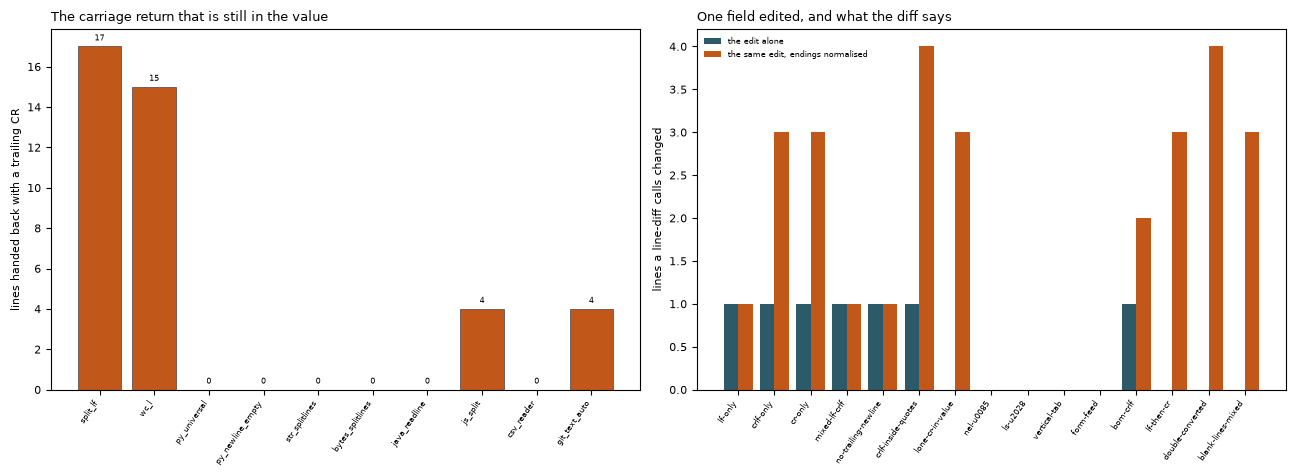

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

INK, WARM, COOL, GREEN, SAND = "#1d2733", "#c2571a", "#2d5a68", "#2f6b39", "#e8d9c0"
plt.rcParams.update({"font.size": 8, "figure.facecolor": "white"})
KEYS = [s.key for s in SPLITTERS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

vals = [cr[k] for k in KEYS]
ax1.bar(range(len(KEYS)), vals, color=[WARM if v else GREEN for v in vals],
        edgecolor=INK, lw=0.4)
for i, v in enumerate(vals):
    ax1.text(i, v + 0.3, str(v), ha="center", fontsize=6)
ax1.set_xticks(range(len(KEYS)))
ax1.set_xticklabels(KEYS, rotation=55, ha="right", fontsize=6)
ax1.set_ylabel("lines handed back with a trailing CR")
ax1.set_title("The carriage return that is still in the value", fontsize=9, loc="left")

x = np.arange(len(blast))
ax2.bar(x - 0.2, [r["edit alone"] for r in blast], 0.4, color=COOL, label="the edit alone")
ax2.bar(x + 0.2, [r["edit + normalise"] for r in blast], 0.4, color=WARM,
        label="the same edit, endings normalised")
ax2.set_xticks(x)
ax2.set_xticklabels([r["file"] for r in blast], rotation=55, ha="right", fontsize=6)
ax2.set_ylabel("lines a line-diff calls changed")
ax2.legend(fontsize=6, frameon=False)
ax2.set_title("One field edited, and what the diff says", fontsize=9, loc="left")

fig.tight_layout()
fig.savefig("eol_notebook.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Summary, and the fix

| mechanism | number |
|---|---|
| files read identically by all ten splitters | 1 of 15 |
| files whose *line count* depends on the reader | 10 of 15 |
| lines handed back with a trailing CR | 40, by 4 of 10 splitters |
| read-then-write runs that change the bytes | 81 of 150 |
| ...of those, runs that move the CSV row count | 11 |
| files whose one-field edit becomes a whole-file diff | 8 of 15 |
| chunk-boundary failures | 15 (file, chunk size) pairs |
| files with no single honest answer to "which line ending?" | 5 of 15 |

The fix, cheapest first:

1. **Read with `newline=''` and a real parser** - for CSV, `csv.reader` over a file opened that way.
2. **Never `split('\n')`** on a payload you did not write.
3. **Never `splitlines()`** on user-supplied text you intend to treat as records.
4. **Write with one chosen terminator**, and terminate the last line.
5. **Normalise once, in its own commit**, with `.gitattributes` alongside.
6. **Return the histogram, not the terminator** - detection is a diagnostic, not a strategy.


In [11]:
checks = {
    "files read identically by all ten": (len(verdicts[Verdict.AGREED]), 1),
    "content-drift files": (len(verdicts[Verdict.CONTENT_DRIFT]), 4),
    "count-drift files": (len(verdicts[Verdict.COUNT_DRIFT]), 9),
    "data-split files": (len(verdicts[Verdict.DATA_SPLIT]), 1),
    "files whose count depends on reader": (len(drifting), 10),
    "lines with a trailing CR": (sum(cr.values()), 40),
    "CR-blind splitters": (sum(1 for v in cr.values() if v), 4),
    "roundtrips that change bytes": (changed, 81),
    "roundtrips that move the row count": (len(inside), 11),
    "whole-file diffs": (sum(1 for r in blast if r["edit + normalise"] > r["edit alone"]), 8),
    "chunk-boundary failures": (len(drift), 15),
    "lines lost by cat": (parts - joined, 1),
    "files with no single EOL answer": (len(no_answer), 5),
}
for label, (got, want) in checks.items():
    print(f"  [{'ok ' if got == want else 'MISMATCH'}] {label:38s} {got} (expected {want})")
assert all(got == want for got, want in checks.values())
print("\nnotebook agrees with the engine on every headline count")

  [ok ] files read identically by all ten      1 (expected 1)
  [ok ] content-drift files                    4 (expected 4)
  [ok ] count-drift files                      9 (expected 9)
  [ok ] data-split files                       1 (expected 1)
  [ok ] files whose count depends on reader    10 (expected 10)
  [ok ] lines with a trailing CR               40 (expected 40)
  [ok ] CR-blind splitters                     4 (expected 4)
  [ok ] roundtrips that change bytes           81 (expected 81)
  [ok ] roundtrips that move the row count     11 (expected 11)
  [ok ] whole-file diffs                       8 (expected 8)
  [ok ] chunk-boundary failures                15 (expected 15)
  [ok ] lines lost by cat                      1 (expected 1)
  [ok ] files with no single EOL answer        5 (expected 5)

notebook agrees with the engine on every headline count


## Try your own file

Point this at a real export - a partner CSV, a log file, anything that came
from another machine.


In [12]:
# with open("your_export.csv", "rb") as fh:
#     data = fh.read()
#
# mine = Blob(0, "yours", data, "")
# print("histogram:", histogram(data))
# for s in SPLITTERS:
#     got = lines(mine, s)
#     bad = sum(1 for ln in got if ln.endswith(CR))
#     print(f"{s.key:18s} {len(got):6d} lines   {bad} with a trailing CR")
# print("verdict:", verdict(mine).value)

---

**Day 151 of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
[project README](README.md) for all ten mechanisms and the findings table,
`python evidence.py` for every number, `python -m pytest -q` for the 42 tests,
`streamlit run app.py` to paste your own bytes.

Previous days on the same theme - an operation that looks total and is not:
[`duration-parser`](../../automation-suite/duration-parser/) (147),
[`percent-recomputer`](../../analytics-engineering-bi/percent-recomputer/) (148),
[`header-casing`](../../automation-suite/header-casing/) (149),
[`sort-order-drift`](../sort-order-drift/) (150).
